In [ ]:
import torch

if torch.cuda.is_available():
    print(f'CUDA is available. GPU: {torch.cuda.get_device_name(0)}')
    print(f'Number of GPUs: {torch.cuda.device_count()}')
else:
    print('CUDA is not available.')

CUDA is available. GPU: Tesla T4
Number of GPUs: 1


In [ ]:
# General Imports
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import keras
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Building Model
from tensorflow.keras import layers, models
from keras.utils import plot_model
from tensorflow.keras import models
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import legacy


# Training Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

# Model Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Data Processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import load_img

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
classes=[]
filename='/kaggle/input/brain-tumor-mri-dataset'
for sub_folder in os.listdir(os.path.join(filename,'Training')):
    classes.append(sub_folder)
print(classes)

['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
train_path='/kaggle/input/brain-tumor-mri-dataset/Training/'
test_path='/kaggle/input/brain-tumor-mri-dataset/Testing/'

In [ ]:
img_list=[]
label_list=[]
for label in classes:
    for img_file in os.listdir(train_path+label):
        img_list.append(train_path+label+'/'+img_file)
        label_list.append(label)

In [ ]:
train_data = pd.DataFrame({'Image':img_list,'Label':label_list})
train_data

,Image,Label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [ ]:
img_list=[]
label_list=[]
for label in classes:
    for img_file in os.listdir(test_path+label):
        img_list.append(test_path+label+'/'+img_file)
        label_list.append(label)

In [ ]:
test_data = pd.DataFrame({'Image':img_list,'Label':label_list})
test_data

,Image,Label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1306,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1307,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1308,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1309,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


In [ ]:
def Plot_Classes(BASE_URL, Rows=2, Columns=5):
    plt.figure(figsize = (25, 8))

    image_count = 1
    for directory in os.listdir(BASE_URL):
        if directory[0] != '.':
            Max_Random = len(os.listdir(os.path.join(BASE_URL,directory)))
            Random_Number = np.random.randint(0, Max_Random)

            for i, file in enumerate(os.listdir(BASE_URL + directory)):
                if i == Random_Number:
                    fig = plt.subplot(Rows, Columns, image_count)
                    image_count += 1

                    image = plt.imread(BASE_URL + directory + '/' + file)
                    plt.imshow(image)
                    plt.title(directory)
                    break

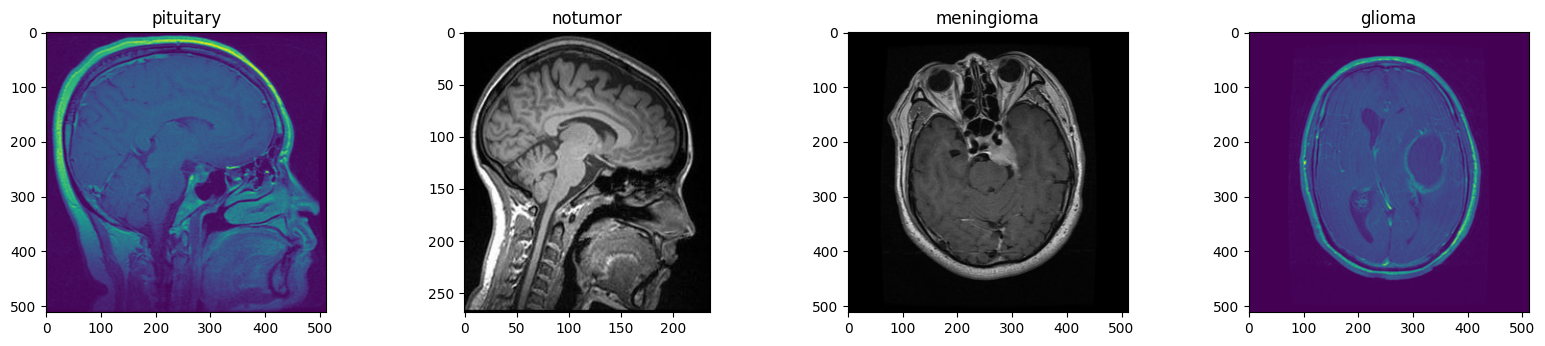

In [ ]:
Plot_Classes(train_path)

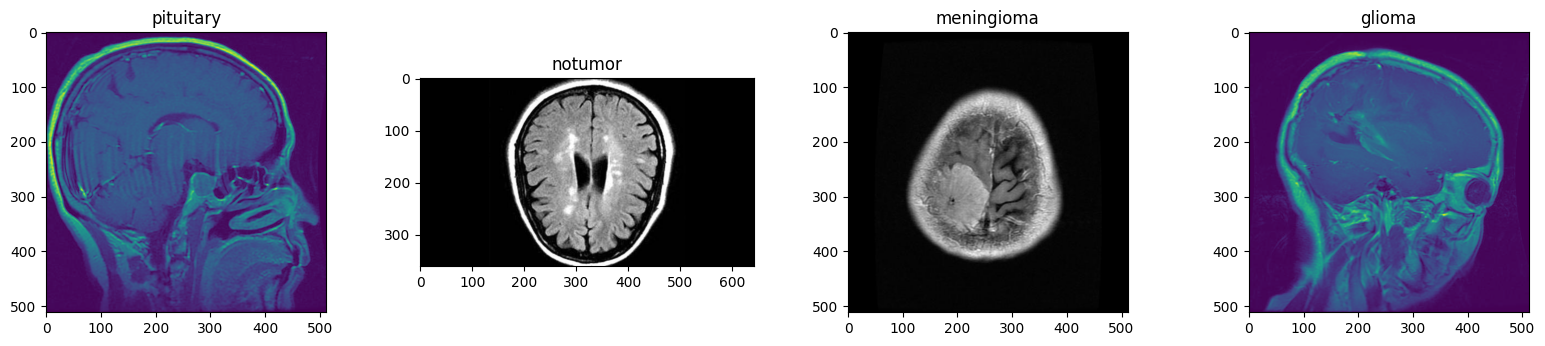

In [ ]:
Plot_Classes(test_path)

In [ ]:
train_data['Label'].value_counts()

,count
Label,
notumor,1595
pituitary,1457
meningioma,1339
glioma,1321


In [ ]:
test_data['Label'].value_counts()

,count
Label,
notumor,405
meningioma,306
pituitary,300
glioma,300


# Data Preprocessing

In [ ]:
# Image size
image_size = (150, 150)

# Training batch size
batch_size = 32

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.15,
                                   rotation_range=10,
                                   brightness_range=(0.85, 1.15),
                                   width_shift_range=0.002,
                                   height_shift_range=0.002,
                                   shear_range=12.5,
                                   zoom_range=0,
                                   horizontal_flip=True,
                                   vertical_flip=False,
                                   fill_mode="nearest")

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

# Creating training data generator
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=image_size,
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    subset='training',
                                                    seed=0)

# Creating validation data generator
val_generator = val_datagen.flow_from_directory(train_path,
                                                target_size=image_size,
                                                batch_size=batch_size,
                                                class_mode='categorical',
                                                subset='validation',
                                                seed=0)

# No augmentation of the test data, just rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# applying the generator to testing data with constant seed
test_generator = test_datagen.flow_from_directory(test_path,
                                                  target_size=image_size,
                                                  batch_size=batch_size,
                                                  class_mode="categorical",
                                                  shuffle=False,
                                                  seed=0)

Found 4857 images belonging to 4 classes.
Found 855 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


# Define Functions for Visualizing Data and Evaluation of models

In [ ]:
def show_ImageDataGenerator(ImageDataGenerator, num_samples=5, figsize=(12, 12), save=False):
    """
    Function to viualize how the ImageDataGenerator augments the data
    """

    # Generate augmented samples
    # Use __next__() instead of next()
    augmented_samples = train_generator.__next__()

    # Extract images from the batch
    images = augmented_samples[0][:num_samples]

    # Display the augmented images
    fig, axes = plt.subplots(1, num_samples, figsize=figsize)

    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()

    if save:
        plt.savefig('show_ImageDataGenerator.pdf')

    plt.show()

In [ ]:
def Show_Model_Accuracy_Loss(model_history):
    """
    Function to visualize the models' accuracy and loss graphs
    """

    plt.figure(figsize=(10, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(model_history.history['accuracy'], color='royalblue', linewidth=2, marker='o')
    plt.plot(model_history.history['val_accuracy'], color='darkorange', linewidth=2, marker='o')
    plt.title('Model Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend(['Train', 'Validation'], fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(model_history.history['loss'], color='forestgreen', linewidth=2, marker='o')
    plt.plot(model_history.history['val_loss'], color='crimson', linewidth=2, marker='o')
    plt.title('Model Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(['Train', 'Validation'], fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)


    plt.tight_layout()
    plt.show()


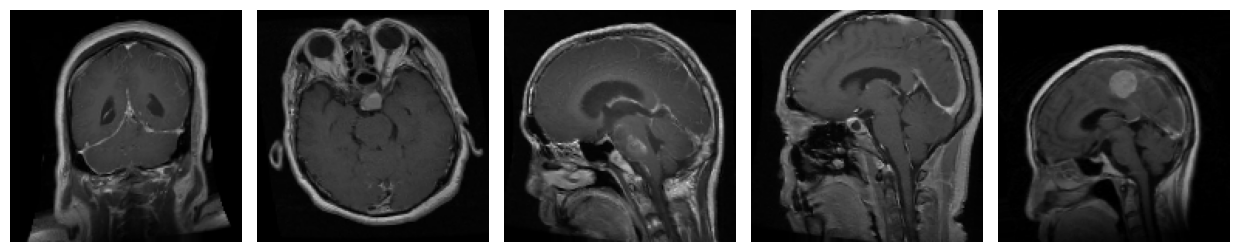

In [ ]:
show_ImageDataGenerator(train_datagen, num_samples=5, figsize=(12.5, 8), save=False)

In [ ]:
# Image shape: height, width, RBG
image_shape = (image_size[0], image_size[1], 3)


print(f'Image shape: {image_shape}')
print(f'Batch size: {batch_size}')
print(f'Number of Train batches: {len(train_generator)}')
print(f'Number of Validation batches: {len(val_generator)}')
print(f'Number of Testing batches: {len(test_generator)}')

Image shape: (150, 150, 3)
Batch size: 32
Number of Train batches: 152
Number of Validation batches: 27
Number of Testing batches: 41


In [ ]:
Classes_Map = train_generator.class_indices
num_classes = len(Classes_Map)

print("Number of Classes:", num_classes)
Classes_Map

Number of Classes: 4


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [ ]:
def CM(model):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    predictions = model.predict(test_generator)
    predicted_categories = np.argmax(predictions, axis=1)

    true_categories = test_generator.classes

    #Print confusion matrix
    confusion_matrix = confusion_matrix(true_categories, predicted_categories)

    print(classification_report(true_categories, predicted_categories,target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']))

    plt.figure(figsize=(10,10))
    sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(ticks=np.arange(4) + 0.5,
               labels=[name.title() for name in classes], ha='center')
    plt.yticks(ticks=np.arange(4) + 0.5,
           labels=[name.title() for name in classes], va='center')
    plt.show()

In [ ]:
model_path_1 = "/content/model_DenseNet121.keras"
model_path_2 = "/content/model_InceptionV3.keras"
model_path_3 = "/content/model_Xception.keras"

In [ ]:
from keras.models import load_model
from sklearn.metrics import accuracy_score

model1 = load_model(model_path_1)
model2 = load_model(model_path_2)
model3 = load_model(model_path_3)

In [ ]:
models = [model1, model2, model3]

preds = [model.predict(test_generator) for model in models]
preds=np.array(preds)
summed = np.sum(preds, axis=0)

# argmax across classes
ensemble_prediction = np.argmax(summed, axis=1)

true_categories = test_generator.classes

prediction1 = model1.predict(test_generator)
Pred_classes_1 = np.argmax(prediction1,axis=1)
accuracy1 = accuracy_score(true_categories, Pred_classes_1)

prediction2 = model2.predict(test_generator)
Pred_classes_2 = np.argmax(prediction2,axis=1)
accuracy2 = accuracy_score(true_categories, Pred_classes_2)

prediction3 = model3.predict(test_generator)
Pred_classes_3 = np.argmax(prediction3,axis=1)
accuracy3 = accuracy_score(true_categories, Pred_classes_3)

41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 559ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 401ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step


In [ ]:
print('Accuracy Score for DenseNet121 = ', accuracy1)
print('Accuracy Score for InceptionV3 = ', accuracy2)
print('Accuracy Score for Xception = ', accuracy3)

Accuracy Score for DenseNet121 =  0.988558352402746
Accuracy Score for InceptionV3 =  0.9931350114416476
Accuracy Score for Xception =  0.9977116704805492


In [ ]:
ensemble_accuracy = accuracy_score(true_categories, ensemble_prediction)


print('Accuracy Score for average ensemble = ', ensemble_accuracy)

Accuracy Score for average ensemble =  0.9969488939740656


In [ ]:
models = [model1, model2, model3]

preds = [model.predict(test_generator) for model in models]
preds=np.array(preds)

weights = [0.2, 0.5, 0.3]

#Use tensordot to sum the products of all elements over specified axes.
weighted_preds = np.tensordot(preds, weights, axes=((0),(0)))
weighted_ensemble_prediction = np.argmax(weighted_preds, axis=1)

weighted_accuracy = accuracy_score(true_categories, weighted_ensemble_prediction)

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step


In [ ]:
print('Accuracy Score for average ensemble = ', ensemble_accuracy*100)
print('Accuracy Score for weighted average ensemble = ', weighted_accuracy*100)

Accuracy Score for average ensemble =  99.69488939740656
Accuracy Score for weighted average ensemble =  99.69488939740656


In [ ]:
preds1 = [model.predict(test_generator) for model in models]
preds1=np.array(preds1)


import pandas as pd

df = pd.DataFrame([])

for w1 in range(0, 9):
    for w2 in range(0, 9):
        for w3 in range(0, 9):
            wts = [w1/10., w2/10., w3/10.]
            wted_preds1 = np.tensordot(preds1, wts, axes=((0),(0)))
            wted_ensemble_pred = np.argmax(wted_preds1, axis=1)
            weighted_accuracy = accuracy_score(true_categories, wted_ensemble_pred)
            df = pd.concat([df, pd.DataFrame.from_records([{'wt1':wts[0], 'wt2':wts[1],'wt3':wts[2],'acc':weighted_accuracy*100}],index=[0])], ignore_index=True)


max_acc_row = df.iloc[df['acc'].idxmax()]
print("Max accuracy of ", max_acc_row[3],"obained with w1 = ", max_acc_row[0],", w2 = ", max_acc_row[1],", w3 = ", max_acc_row[2])

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step
Max accuracy of  99.77116704805492 obained with w1 =  0.0 , w2 =  0.0 , w3 =  0.1


              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



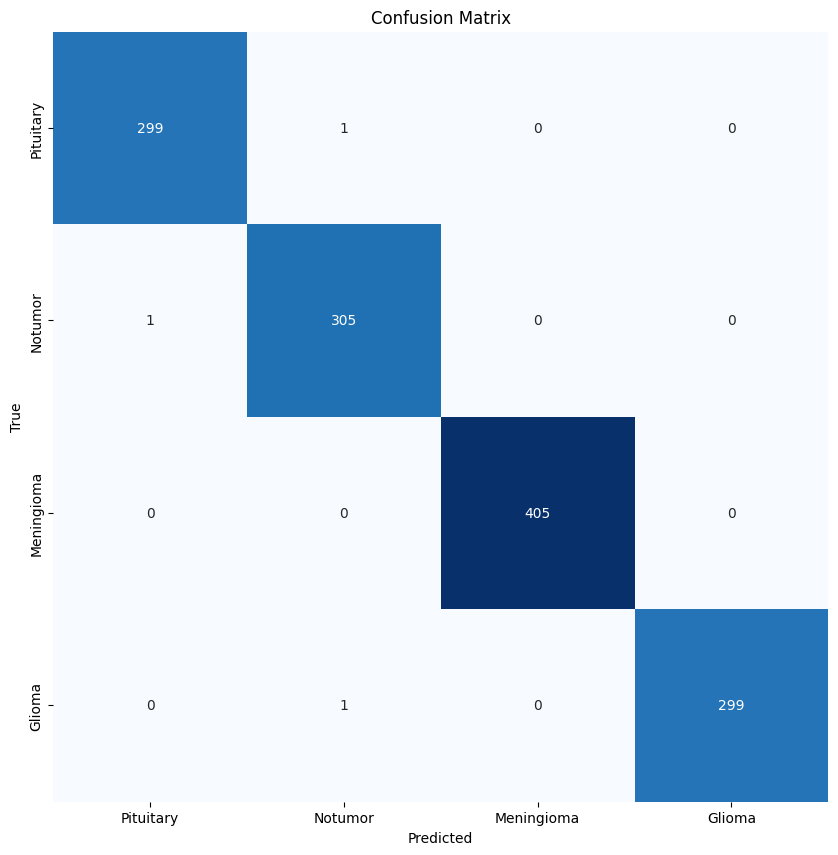

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

ideal_weights = [0.0, 0.0, 0.1]  # weights for 4 models

# Weighted ensemble prediction
ideal_weighted_ensemble_preds = np.tensordot(preds, ideal_weights, axes=((0), (0)))
ideal_weighted_ensemble_prediction = np.argmax(ideal_weighted_ensemble_preds, axis=1)

# Flatten to (1909,)
ideal_weighted_ensemble_prediction = ideal_weighted_ensemble_prediction.ravel()

# Confusion matrix
cm = confusion_matrix(true_categories, ideal_weighted_ensemble_prediction)

# Classification report
print(classification_report(
    true_categories,
    ideal_weighted_ensemble_prediction,
    target_names=['glioma', 'meningioma', 'notumor', 'pituitary']
))

# Heatmap
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(4) + 0.5, labels=[name.title() for name in classes], ha='center')
plt.yticks(ticks=np.arange(4) + 0.5, labels=[name.title() for name in classes], va='center')
plt.show()

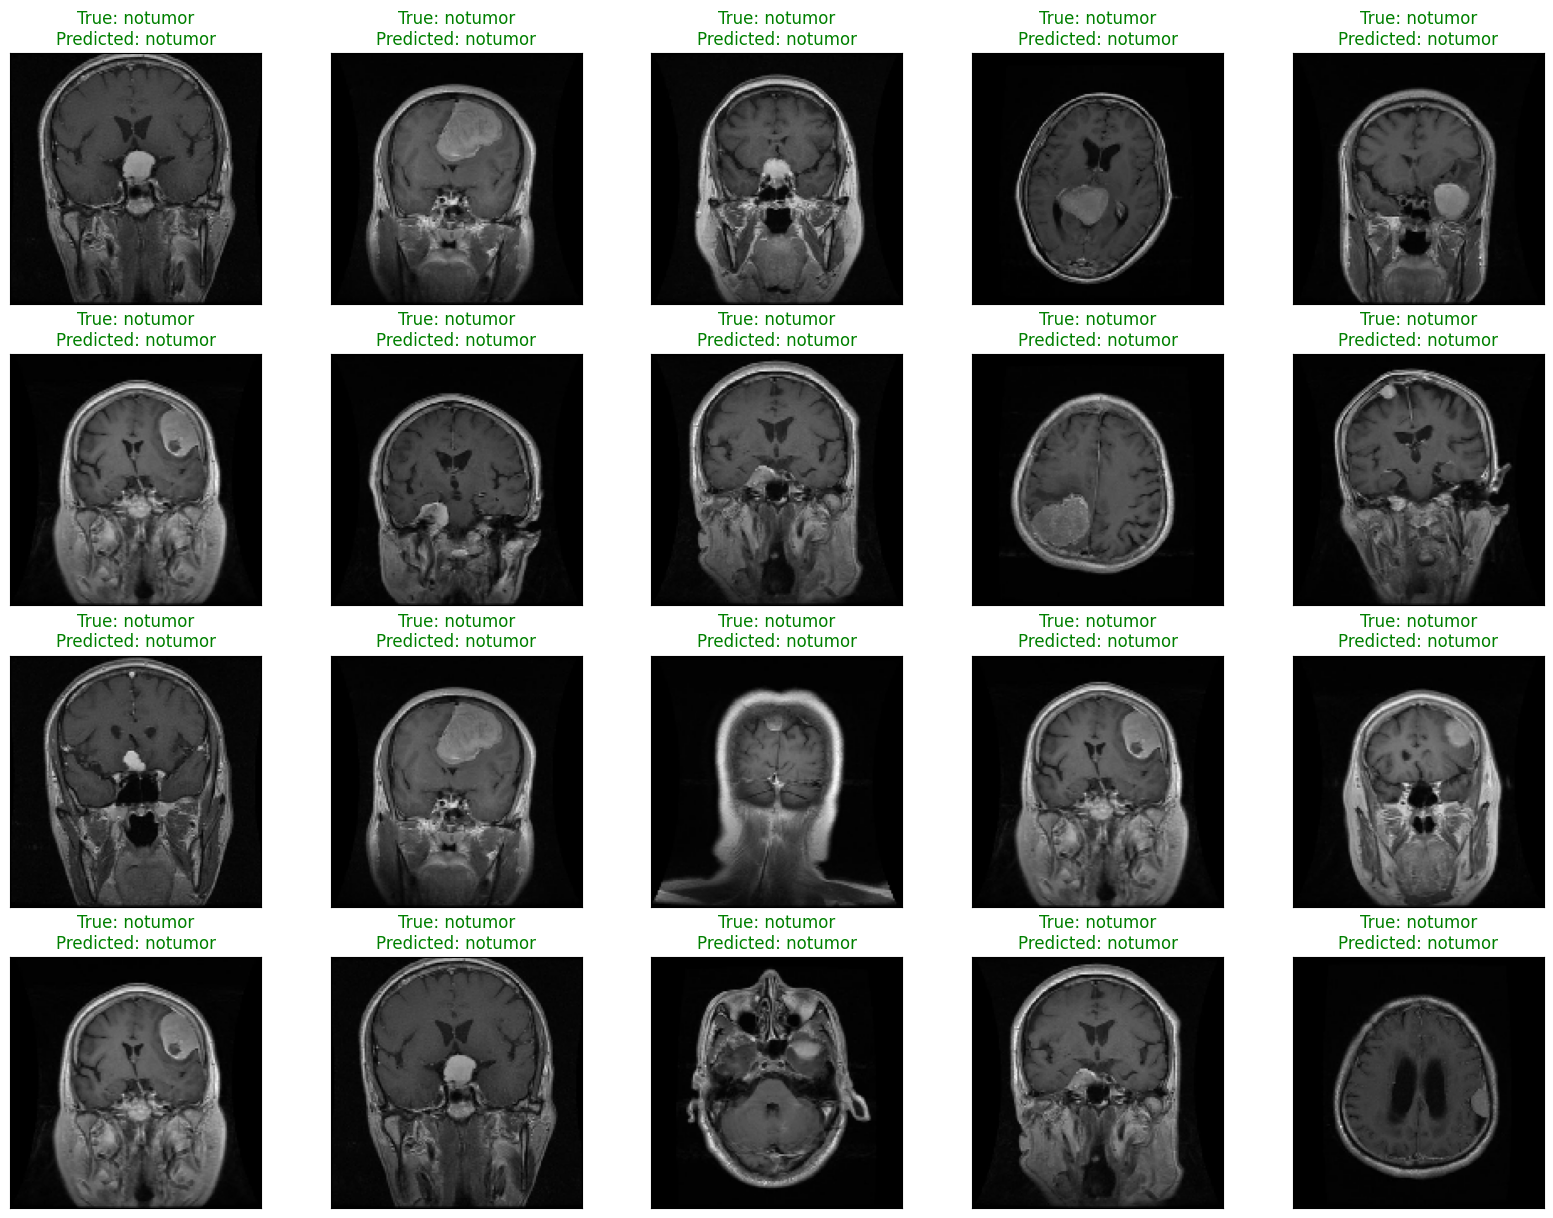

<Figure size 640x480 with 0 Axes>

In [ ]:
# Display 20 random pictures predictions from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator))

Random_Img_Index = np.random.randint(0, batch_size , 20)

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]
    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    # Ensemble model prediction
    models = [model1, model2, model3]
    preds = [model.predict(tf.expand_dims(Random_Img, axis=0) , verbose=0) for model in models]
    preds=np.array(preds)

    Model_Predictions = np.tensordot(preds, ideal_weights, axes=((0),(0))) # Ensemble model prediction


    Model_Highest_Prediction = np.argmax(Model_Predictions)


    ax.imshow(Random_Img)

    Pred_Class = classes[Model_Highest_Prediction]

    if classes[Random_Img_Label] == Pred_Class:
      color = "green"
    else:
      color = "red"
    ax.set_title(f"True: {classes[Random_Img_Label]}\nPredicted: {Pred_Class}", color=color)

plt.show()
plt.tight_layout()

In [ ]:
from sklearn.metrics import confusion_matrix

def multiclass_specificity(true_categories, ideal_weighted_ensemble_prediction, average=None):
    """
    Compute specificity for multiclass classification.

    Parameters:
    - y_true: true labels (1D array)
    - y_pred: predicted labels (1D array)
    - average: None | 'macro' | 'weighted'

    Returns:
    - dict of per-class specificity or averaged score
    """
    true_categories = test_generator.classes
    labels = np.unique(true_categories)
    cm = confusion_matrix(true_categories, ideal_weighted_ensemble_prediction, labels=labels)

    specificities = {}
    for i, label in enumerate(labels):
        # One-vs-all calculation
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities[label] = specificity

    if average == 'macro':
        return np.mean(list(specificities.values()))
    elif average == 'weighted':
        weights = [(true_categories == lbl).sum() for lbl in labels]
        return np.average(list(specificities.values()), weights=weights)
    else:
        return specificities

In [ ]:
result = multiclass_specificity(true_categories, ideal_weighted_ensemble_prediction)
print("Specificity per class:", result)

# Optionally
print("Macro-average specificity:", multiclass_specificity(true_categories, ideal_weighted_ensemble_prediction, average='macro'))

print("Macro-weighted specificity:", multiclass_specificity(true_categories, ideal_weighted_ensemble_prediction, average='weighted'))

Specificity per class: {np.int32(0): np.float64(0.9990108803165183), np.int32(1): np.float64(0.9980099502487563), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}
Macro-average specificity: 0.9992552076413186
Macro-weighted specificity: 0.9993091600847253


In [ ]:
from sklearn.metrics import matthews_corrcoef

# MCC calculation
mcc = matthews_corrcoef(true_categories, ideal_weighted_ensemble_prediction)
print("MCC:", mcc)

MCC: 0.9969306500348278


In [ ]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

# Step 1: One-hot encode y_true for PR AUC
n_classes = ideal_weighted_ensemble_preds.shape[1]
y_true_bin = label_binarize(true_categories, classes=np.arange(n_classes))

# Step 2: Compute PR AUC for each class
pr_auc_per_class = {}
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], ideal_weighted_ensemble_preds[:, i])
    pr_auc_per_class[i] = auc(recall, precision)

# Step 3: Macro-average PR AUC
macro_pr_auc = np.mean(list(pr_auc_per_class.values()))

# Optional: Weighted-average PR AUC
weighted_pr_auc = average_precision_score(y_true_bin, ideal_weighted_ensemble_preds, average='weighted')

# Print results
print("Per-class PR AUC:", pr_auc_per_class)
print("Macro-average PR AUC:", macro_pr_auc)
print("Weighted-average PR AUC:", weighted_pr_auc)

Per-class PR AUC: {0: np.float64(0.9997057324486619), 1: np.float64(0.9984445061928897), 2: np.float64(1.0), 3: np.float64(0.9987061614011657)}
Macro-average PR AUC: 0.9992141000106793
Weighted-average PR AUC: 0.9992747429712288


In [ ]:
from sklearn.metrics import f1_score

# true_categories: true labels, shape (n_samples,)
# ideal_weighted_ensemble_prediction: predicted labels, shape (n_samples,)

# Per-class F1 score
f1_per_class = f1_score(true_categories, ideal_weighted_ensemble_prediction, average=None)

# Macro-average F1 (unweighted mean of per-class scores)
f1_macro = f1_score(true_categories, ideal_weighted_ensemble_prediction, average='macro')

# Weighted-average F1 (accounts for class imbalance)
f1_weighted = f1_score(true_categories, ideal_weighted_ensemble_prediction, average='weighted')

# Print results
print("Per-class F1 Score:", f1_per_class)
print("Macro-average F1 Score:", f1_macro)
print("Weighted-average F1 Score:", f1_weighted)

Per-class F1 Score: [0.99666667 0.99510604 1.         0.99833055]
Macro-average F1 Score: 0.9975258133684834
Weighted-average F1 Score: 0.9977129002727038
